In [2]:
import pandas as pd
import os
from utils import get_df_metrics, get_heatmap, load_json
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report


In [74]:
def return_binary_classification(result):
    if "CLASSIFICATION: NOT KEY CASE" in result:
        print('0 == ',result)
        return 0
    else:
        #print('1 == ',result)
        return 1


def transalte_importance_score(importance):
    if importance in ["2", "3", "4"]:
        return 0
    else:
        return 1

def get_df(output_dir = './results_facts_openai/', keep_classes= [1,2,3,4]):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        result_data = load_json(os.path.join(output_dir, result))
        if int(result_data["importance"]) not in keep_classes:
            continue
        data.append(
            {
                'importance_level': int(result_data['importance']),
                "classification": return_binary_classification(
                    result_data["result"]["classification_reasoning"]
                ),
                "ground_truth": transalte_importance_score(result_data["importance"]),
            }
        )

    df = pd.DataFrame(data)
    return df

def get_heatmap(df: pd.DataFrame, target_col: str, pred_col: str):
    """Plot and display a heatmap of the confusion matrix."""
    import seaborn as sns
    import matplotlib.pyplot as plt

    cm = confusion_matrix(df[target_col], df[pred_col], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


def get_metrics_binary(df):
    # Key Case vs. All
    # Ground truth: 1 for key case, 0 for not key case
    y_true = df['ground_truth']
    # Model predictions: 1 for key case, 0 for not key case
    y_pred = df['classification']

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary")
    recall = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    # Classification report for additional insights
    rreport = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"], output_dict=True)
    report = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"])

    # Extracting micro and macro F1 scores
    micro_f1 = rreport["accuracy"]  # Micro F1 is equivalent to accuracy in binary classification
    macro_f1 = rreport["macro avg"]["f1-score"]

    # Presenting results
    metrics = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
    }
    return metrics, report


In [75]:
output_dir = './results_facts_openai/'
df = get_df(output_dir, keep_classes=[1,2,3,4])
metrics, report = get_metrics_binary(df)
metrics

0 ==  To classify the case based on the provided facts, we need to analyze the significance of the case in relation to the development of legal principles and its implications beyond the immediate dispute. 

### Step-by-Step Analysis:

1. **Nature of the Case**: The case involves the dismissal of employees based on evidence obtained through covert video surveillance. The applicants argue that their right to privacy was violated, and they challenge the legality of the evidence used against them.

2. **Legal Framework**: The case touches upon several important legal principles, including:
   - The right to privacy as protected under the Spanish Constitution and relevant European human rights law.
   - The legality of video surveillance in the workplace, particularly covert surveillance, and the necessity of prior notification to employees.
   - The balance between an employer's right to monitor employees and the employees' right to privacy.

3. **Judicial Proceedings**: The case has gone

{'Accuracy': 0.598,
 'Precision': 0.348,
 'Recall': 0.696,
 'F1 Score': 0.464,
 'Micro F1': 0.598,
 'Macro F1': 0.5712}

In [71]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.85      0.57      0.68       375
    Key Case       0.35      0.70      0.46       125

    accuracy                           0.60       500
   macro avg       0.60      0.63      0.57       500
weighted avg       0.72      0.60      0.62       500



In [51]:
output_dir = './results_facts_openai/'
df = get_df(output_dir, keep_classes=[1,2])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.52,
 'Precision': 0.5182481751824818,
 'Recall': 0.568,
 'F1 Score': 0.5419847328244275,
 'Micro F1': 0.52,
 'Macro F1': 0.5188915260760794}

In [52]:
output_dir = './results_facts_openai/'
df = get_df(output_dir, keep_classes=[1,3])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.616,
 'Precision': 0.6283185840707964,
 'Recall': 0.568,
 'F1 Score': 0.5966386554621849,
 'Micro F1': 0.616,
 'Macro F1': 0.6151132208608634}

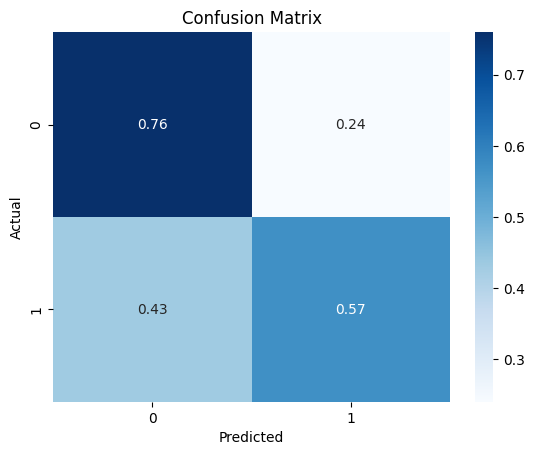

{'Accuracy': 0.664,
 'Precision': 0.7029702970297029,
 'Recall': 0.568,
 'F1 Score': 0.6283185840707964,
 'Micro F1': 0.664,
 'Macro F1': 0.6608746205025515}

In [53]:
output_dir = './results_facts_openai/'
df = get_df(output_dir, keep_classes=[1,4])
metrics, report = get_metrics_binary(df)
get_heatmap(df, "ground_truth", "classification")

metrics

In [76]:
output_dir = './results_facts_law_openai/'
df = get_df(output_dir, keep_classes=[1,2,3,4])
metrics, report = get_metrics_binary(df)
metrics

0 ==  To classify the case based on the provided facts and legal analysis, we need to evaluate the significance of the case in terms of its contribution to the development of case law, the establishment of new legal principles, and its broader implications.

### Step-by-Step Reasoning:

1. **Case Background**: The case involves the dismissal of employees from a supermarket based on evidence obtained through covert video surveillance. The employees argued that their right to privacy was violated, and the legality of the evidence used in their dismissal was contested.

2. **Legal Framework**: The case is analyzed under Article 8 of the European Convention on Human Rights (ECHR), which protects the right to respect for private life, and Article 6, which guarantees the right to a fair trial. The domestic courts had to balance the employer's right to monitor for theft against the employees' right to privacy.

3. **Domestic Court Findings**: The domestic courts upheld the employer's actions,

{'Accuracy': 0.556,
 'Precision': 0.3367003367003367,
 'Recall': 0.8,
 'F1 Score': 0.47393364928909953,
 'Micro F1': 0.556,
 'Macro F1': 0.5449253021532003}

In [73]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.88      0.47      0.62       375
    Key Case       0.34      0.80      0.47       125

    accuracy                           0.56       500
   macro avg       0.61      0.64      0.54       500
weighted avg       0.74      0.56      0.58       500



In [55]:
output_dir = './results_facts_law_openai/'
df = get_df(output_dir, keep_classes=[1,2])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.48,
 'Precision': 0.4869109947643979,
 'Recall': 0.744,
 'F1 Score': 0.5886075949367089,
 'Micro F1': 0.48,
 'Macro F1': 0.44104292790313704}

In [56]:
output_dir = './results_facts_law_openai/'
df = get_df(output_dir, keep_classes=[1,3])
metrics, report = get_metrics_binary(df)
metrics

{'Accuracy': 0.56,
 'Precision': 0.543859649122807,
 'Recall': 0.744,
 'F1 Score': 0.6283783783783784,
 'Micro F1': 0.56,
 'Macro F1': 0.5445813460519343}

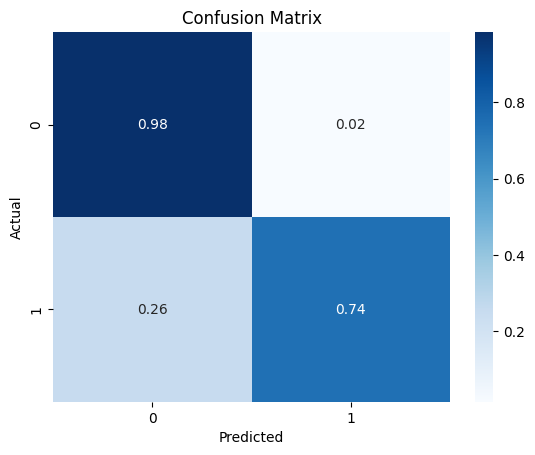

{'Accuracy': 0.864,
 'Precision': 0.9789473684210527,
 'Recall': 0.744,
 'F1 Score': 0.8454545454545455,
 'Micro F1': 0.864,
 'Macro F1': 0.862012987012987}

In [57]:
output_dir = './results_facts_law_openai/'
df = get_df(output_dir, keep_classes=[1,4])
metrics, report = get_metrics_binary(df)
get_heatmap(df, "ground_truth", "classification")
metrics